In [6]:
import pandas as pd
import numpy as np
# Import the components from your separate file
from bl_backtest_engine import *

In [ ]:
# 1. Load the pre-computed Q matrix into memory
# Ensure the index is a proper pandas DatetimeIndex and sorted
q_matrix_df = pd.read_csv("Q_matrix.csv", index_col=0, parse_dates=True)
q_matrix_df = q_matrix_df.sort_index()

# 2. Define the custom builder
def sentiment_q_builder(
    y_monthly_train: np.ndarray,
    X_monthly_train: np.ndarray,
    X_current: np.ndarray,
    current_date: pd.Timestamp,
    assets: list,
    **kwargs
) -> tuple[np.ndarray, np.ndarray]:
    """
    Fetches the pre-computed sentiment expected returns for the given rebalancing date.
    """
    # Fetch the Q vector for the current month
    try:
        # If your Q matrix dates perfectly match the market data end-of-month dates
        q_views = q_matrix_df.loc[current_date, assets].values
    except KeyError:
        # Fallback: forward-fill to get the latest available sentiment view prior to the current_date
        q_views = q_matrix_df.asof(current_date)[assets].values
    
    # The default engine expects a residual_variances array to calculate Omega.
    # Since your Q comes from ML sentiment rather than a traditional regression, 
    # explicit error bounds might not exist. We can pass an array of small dummy values 
    # because we will override the Omega calculation method later.
    residual_variances = np.ones(len(assets)) * 0.01
    
    return np.asarray(q_views, dtype=float), residual_variances

In [2]:
# read stock and etf tickers
stock_returns = pd.read_csv("stock_returns.csv")
etf_returns = pd.read_csv("etf_returns.csv")

stock_returns["date"] = pd.to_datetime(stock_returns["date"])

etf_returns["date"] = pd.to_datetime(etf_returns["date"])

tickers = stock_returns.columns.tolist() + etf_returns.columns.tolist()

                      Sentiment Quantamental Equal Weight
Annualized Return                      5.17%       17.10%
Sharpe Ratio                           0.316        1.145
Information Ratio                     -1.820          N/A
Maximum Drawdown                     -27.96%      -20.29%
Annualized Volatility                 16.38%       14.94%
Value at Risk (95%)                   -6.63%       -5.27%
Annualized Turnover                  525.97%        0.00%


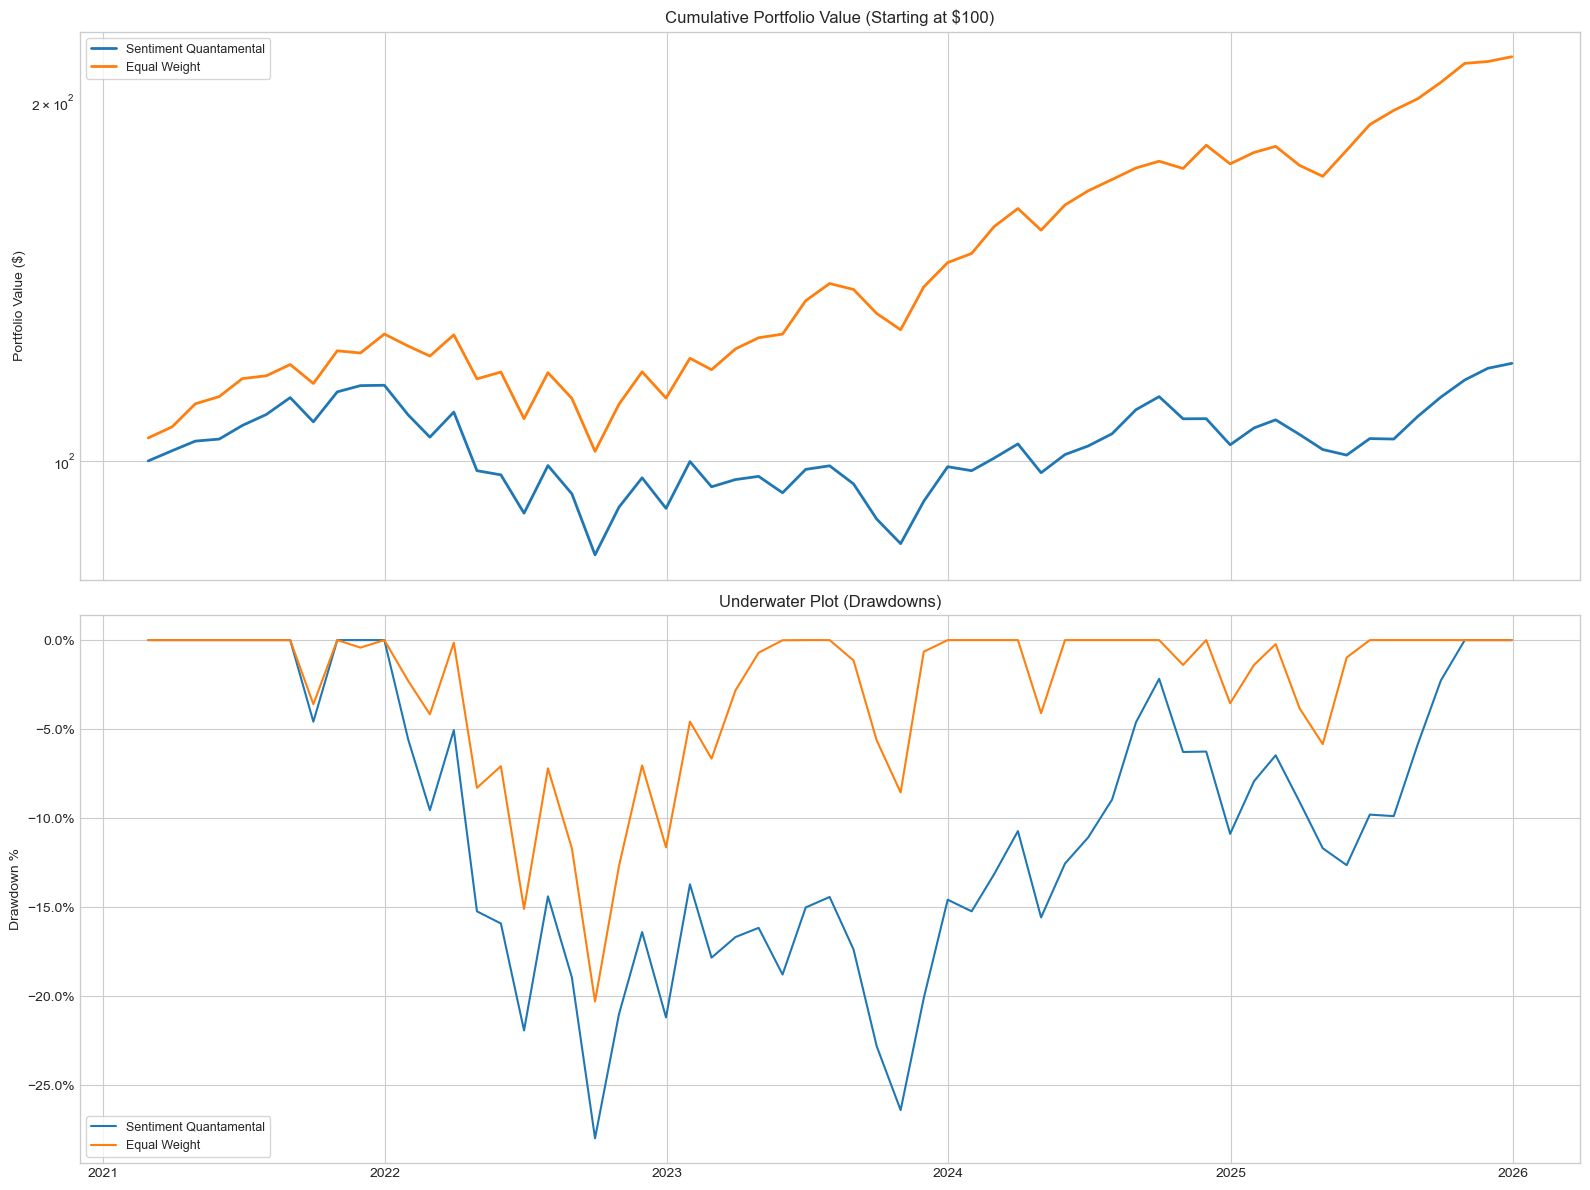

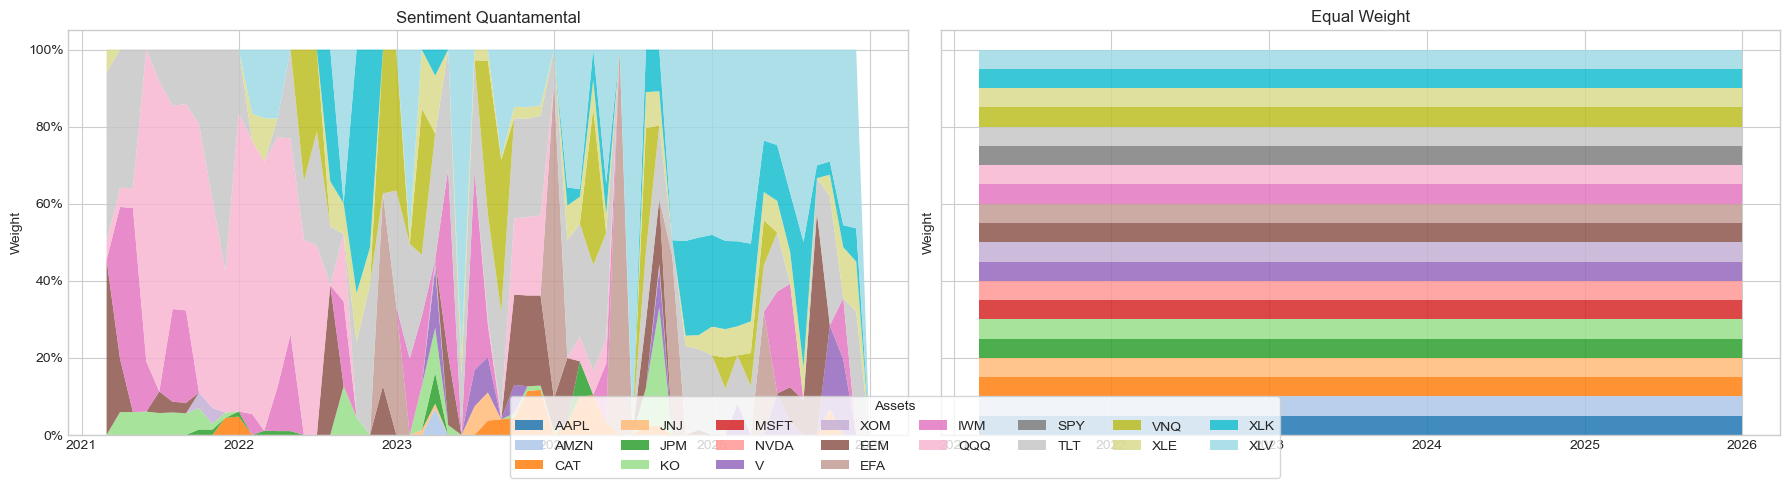

In [8]:
# Initialize your configuration
config = BacktestConfig(
    assets= tickers, # Update with your specific universe
    start_date="2015-01-02",
    end_date="2025-12-30",
    window_months=60,
    tau=0.05 # Adjust this to increase/decrease the weight of your sentiment views
)

# Fetch market data and macro factors (macro_df is required by the engine loop even if unused in Q)
daily_rets, monthly_rets, macro_df = prepare_data(config)

# Run the Quantamental Backtest
sentiment_results = run_single_strategy_backtest(
    config=config,
    monthly_rets=monthly_rets,
    daily_rets=daily_rets,
    macro_df=macro_df,
    strategy_name="Sentiment Quantamental Portfolio",
    build_q_views_fn=sentiment_q_builder, # <-- Injecting your ML views here
    omega_method="subjective"             # <-- Best practice for external ML signals
)

# Run Equal Weight Benchmark for comparison
ew_results = build_equal_weight_benchmark(monthly_rets, config.window_months)

# Evaluate and Export
all_results = {
    "Sentiment Quantamental": sentiment_results,
    "Equal Weight": ew_results
}

metrics_report = evaluate_strategies(all_results, benchmark_name="Equal Weight")
formatted_report = format_metrics_table(metrics_report)
print(formatted_report)

export_results(metrics_report, all_results, config.result_dir)